# Inferência — rastreamento identity-aware com a MotionRNN (PA2)

Recebe o caminho de **uma sequência qualquer no formato MOTChallenge** (`img1/`, `seqinfo.ini`,
`det/det.txt` opcional, `gt/gt.txt` opcional) e devolve:

* um vídeo `.mp4` com as identidades coloridas de forma consistente (cor = função do id);
* a contagem de objetos únicos;
* se houver `gt/gt.txt`, as métricas próprias (IDF1, ID switches, fragmentações).

Roda **sem retreinar**: só carrega o checkpoint. Se a sequência não tiver `det/det.txt`, liga-se
`USE_TORCHVISION = True` para detectar com o Faster R-CNN pré-treinado (classe person, NMS próprio).

In [1]:
# ---- parâmetros -------------------------------------------------------------
SEQ_PATH = "data/synth_demo/SYNTH-DEMO"   # ex.: "data/MOT17/train/MOT17-10-FRCNN"
CKPT = None            # None = escolhe pelo tamanho da imagem (sintético vs MOT17)
DET_FILE = None        # None = det/det.txt da sequência
USE_TORCHVISION = False
OUT_VIDEO = "results/inferencia.mp4"
MAX_FRAMES = 0         # 0 = todos

In [2]:
import os, sys, numpy as np, cv2
sys.path.insert(0, os.path.abspath("."))
from pa2.data import load_mot_sequence
from pa2.models import MotionRNN
from pa2.evaluate import tracker_params, run_tracker
from metrics import evaluate_tracking

seq_dir = SEQ_PATH
det_file = DET_FILE
if USE_TORCHVISION or not os.path.exists(os.path.join(seq_dir, "det", "det.txt")):
    from pa2.detect import load_detector, detect_images
    import glob
    paths = sorted(glob.glob(os.path.join(seq_dir, "img1", "*.jpg")))
    det, tf = load_detector()
    d = detect_images(paths, det, tf)
    det_file = os.path.join(seq_dir, "det", "det_tv.txt")
    os.makedirs(os.path.dirname(det_file), exist_ok=True)
    np.savetxt(det_file, np.column_stack([d[:, 0], -np.ones(len(d)), d[:, 1], d[:, 2], d[:, 3] - d[:, 1],
               d[:, 4] - d[:, 2], d[:, 5], -np.ones((len(d), 3))]), delimiter=",", fmt="%.4f")
seq = load_mot_sequence(seq_dir, det_file=det_file)
data = "synth" if seq.width <= 256 else "mot17"
if data == "synth":
    seq.min_vis = 0.2
ckpt = CKPT or f"checkpoints/{data}_gru.pt"
model, ck = MotionRNN.from_checkpoint(ckpt)
print(seq.name, f"{seq.width}x{seq.height}", seq.n_frames, "quadros,", len(seq.dets), "detecções |",
      "checkpoint:", ckpt, ck["model_config"])

SYNTH-DEMO 128x128 60 quadros, 391 detecções | checkpoint: checkpoints/synth_gru.pt {'cell': 'gru', 'hidden': 61, 'head': 64}


In [3]:
if MAX_FRAMES:
    seq.n_frames = min(seq.n_frames, MAX_FRAMES)
kw = tracker_params(data, "rnn")
pred = run_tracker(seq, "rnn", model, **kw)
print("parâmetros de associação:", kw)
print("OBJETOS ÚNICOS (identidades previstas):", len(np.unique(pred[:, 1])))
if len(seq.gt_full):
    m = evaluate_tracking(seq.gt[seq.gt[:, 0] <= seq.n_frames], pred, ignore=seq.ignore_all)
    print("identidades verdadeiras:", m["n_gt_ids"])
    print({k: round(m[k], 4) if isinstance(m[k], float) else m[k]
           for k in ["IDF1", "IDP", "IDR", "IDSW", "Frag", "MOTA", "count_err"]})

parâmetros de associação: {'iou_thr': 0.2, 'max_age': 30, 'min_hits': 2, 'det_thr': 0.5, 'new_thr': 0.6, 'matcher': 'greedy', 'maha_gate': 13.28}
OBJETOS ÚNICOS (identidades previstas): 11
identidades verdadeiras: 10
{'IDF1': 0.8679, 'IDP': 0.9517, 'IDR': 0.7976, 'IDSW': 1, 'Frag': 41, 'MOTA': 0.8119, 'count_err': 1}


In [4]:
def color(i):
    rng = np.random.default_rng(int(i) * 7919 + 13)
    return tuple(int(c) for c in rng.integers(40, 255, 3))

scale = max(1, int(round(640 / seq.width)))
os.makedirs(os.path.dirname(OUT_VIDEO) or ".", exist_ok=True)
H, W = seq.height * scale, seq.width * scale
vw = cv2.VideoWriter(OUT_VIDEO, cv2.VideoWriter_fourcc(*"mp4v"), seq.fps, (W, H))
seen, snapshots = set(), []
for f in range(1, seq.n_frames + 1):
    img = cv2.resize(seq.image(f)[..., ::-1].copy(), (W, H), interpolation=cv2.INTER_NEAREST)
    for r in pred[pred[:, 0] == f]:
        tid = int(r[1]); seen.add(tid)
        x1, y1, x2, y2 = (r[2:6] * scale).astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), color(tid), 2)
        cv2.putText(img, str(tid), (x1, max(12, y1 - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color(tid), 2)
    cv2.putText(img, f"frame {f}  ids unicos: {len(seen)}", (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (255, 255, 255), 2)
    vw.write(img)
    if f in np.linspace(1, seq.n_frames, 4).astype(int):
        snapshots.append(img[..., ::-1])
vw.release()
print("vídeo salvo em", OUT_VIDEO, "| objetos únicos:", len(seen))

vídeo salvo em results/inferencia.mp4 | objetos únicos: 11


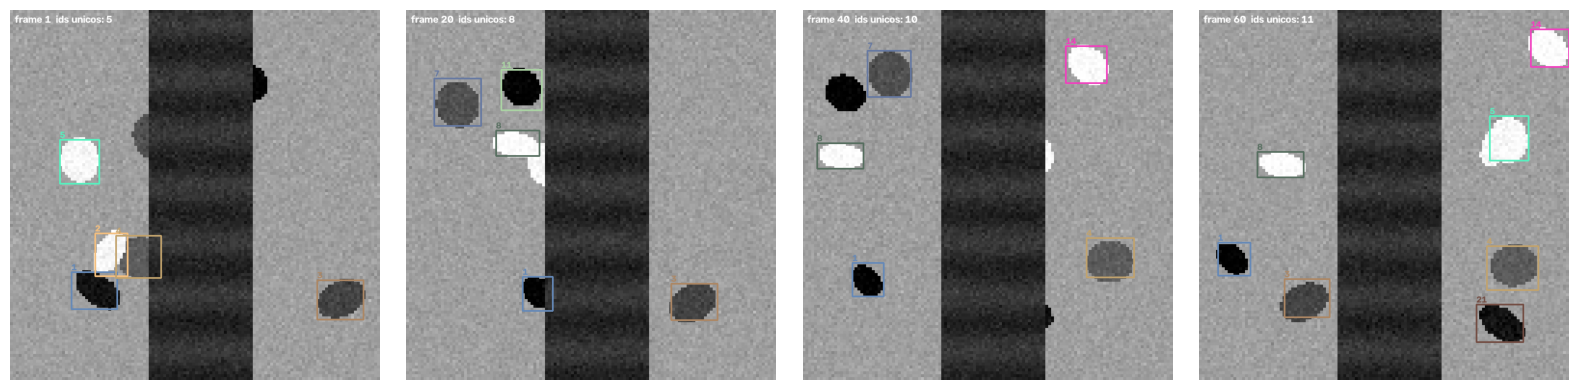

In [5]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
for ax, im in zip(axs, snapshots):
    ax.imshow(im); ax.axis("off")
plt.tight_layout(); plt.show()